In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/insurance.csv')
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Cleaning and Preprocessing

In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
print('\nData types of each column:')
df.info()


Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
print('\nDataFrame after one-hot encoding:')
display(df_encoded.head())


DataFrame after one-hot encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Exploratory Data Analysis (EDA)

In [ ]:
print('Descriptive statistics for numerical columns:')
display(df_encoded.describe())

Descriptive statistics for numerical columns:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


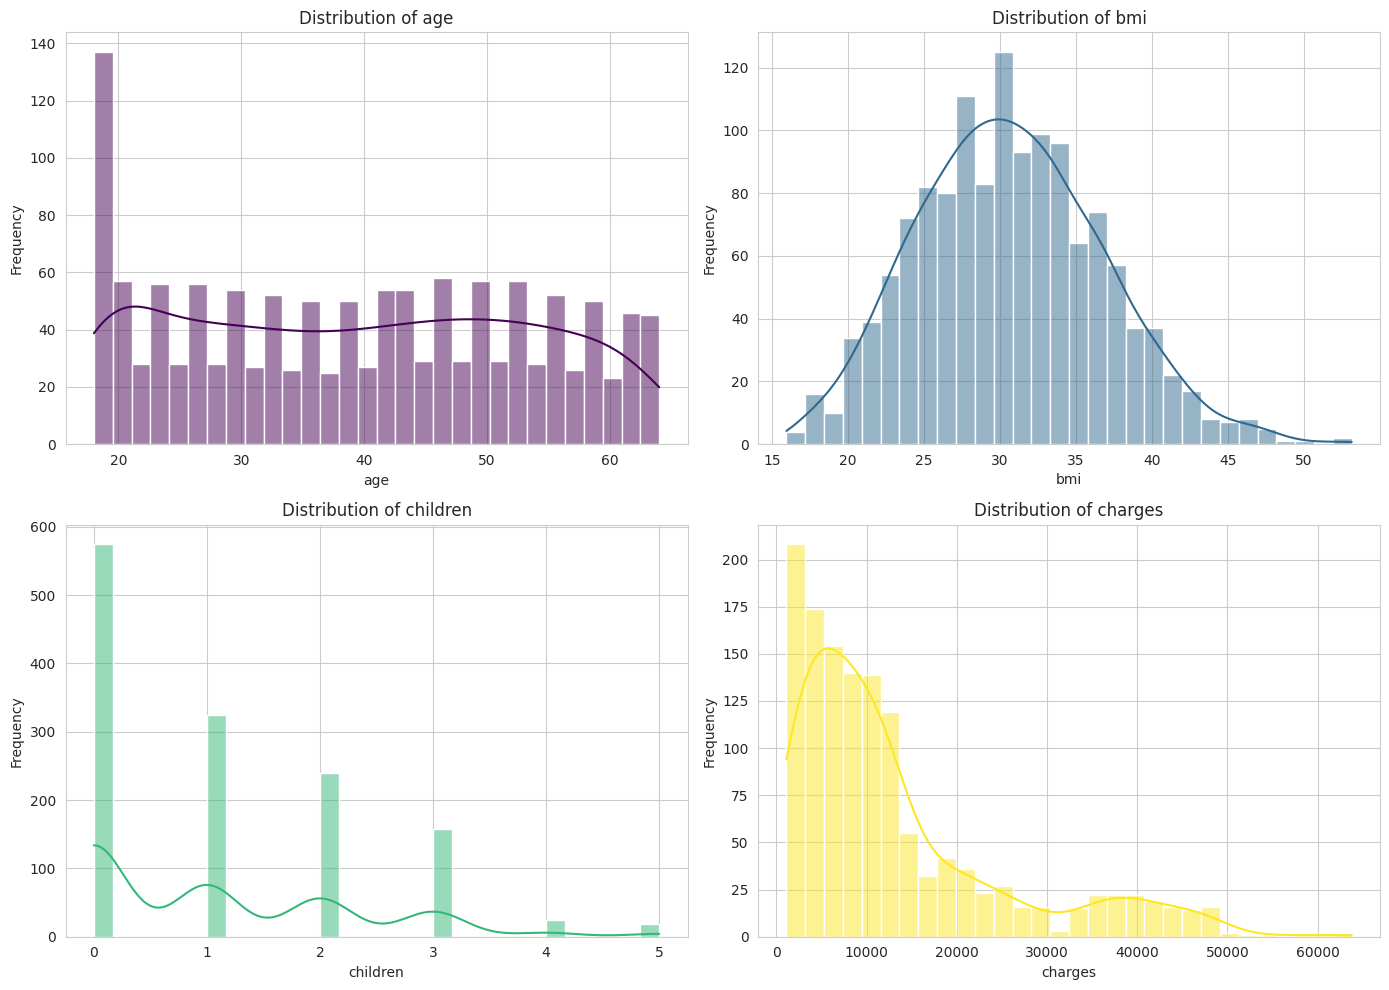

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Identify numerical columns for histograms
numerical_cols = ['age', 'bmi', 'children', 'charges']

# Get a colormap and select colors for each histogram
colors = cm.viridis(np.linspace(0, 1, len(numerical_cols)))

# Create histograms for numerical features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df_encoded[col], kde=True, ax=axes[i], bins=30, color=colors[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Feature Engineering and Selection

In [ ]:
# Create a copy to avoid modifying the original encoded DataFrame directly
df_fe = df_encoded.copy()

# 1. Age-BMI Interaction
df_fe['bmi_age_interaction'] = df_fe['bmi'] * df_fe['age']

# 2. BMI Categories (e.g., Underweight, Normal, Overweight, Obese)
def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'

df_fe['bmi_category'] = df_fe['bmi'].apply(get_bmi_category)

# One-hot encode the new bmi_category feature
df_fe = pd.get_dummies(df_fe, columns=['bmi_category'], drop_first=True)

# 3. Log transformation for 'charges' due to its skewed distribution
df_fe['charges_log'] = np.log1p(df_fe['charges']) # log1p handles zero values gracefully

print('DataFrame after feature engineering:')
display(df_fe.head())

DataFrame after feature engineering:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age_interaction,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,charges_log
0,19,27.900,0,16884.92400,False,True,False,False,True,530.100,False,True,False,9.734236
1,18,33.770,1,1725.55230,True,False,False,True,False,607.860,True,False,False,7.453882
2,28,33.000,3,4449.46200,True,False,False,True,False,924.000,True,False,False,8.400763
3,33,22.705,0,21984.47061,True,False,True,False,False,749.265,False,False,False,9.998137
4,32,28.880,0,3866.85520,True,False,True,False,False,924.160,False,True,False,8.260455


We've created a few new features:

*   **`bmi_age_interaction`**: An interaction term combining BMI and age, which might capture synergistic effects on insurance charges.
*   **`bmi_category`**: Categorical bins for BMI (Underweight, Normal, Overweight, Obese), one-hot encoded into new columns.
*   **`charges_log`**: A log-transformed version of the `charges` column, which can help normalize its highly skewed distribution for better model performance.

Descriptive statistics for log-transformed charges:


,charges_log
count,1338.000000
mean,9.098828
std,0.919379
min,7.023647
25%,8.464064
50%,9.146658
75%,9.719618
max,11.063061


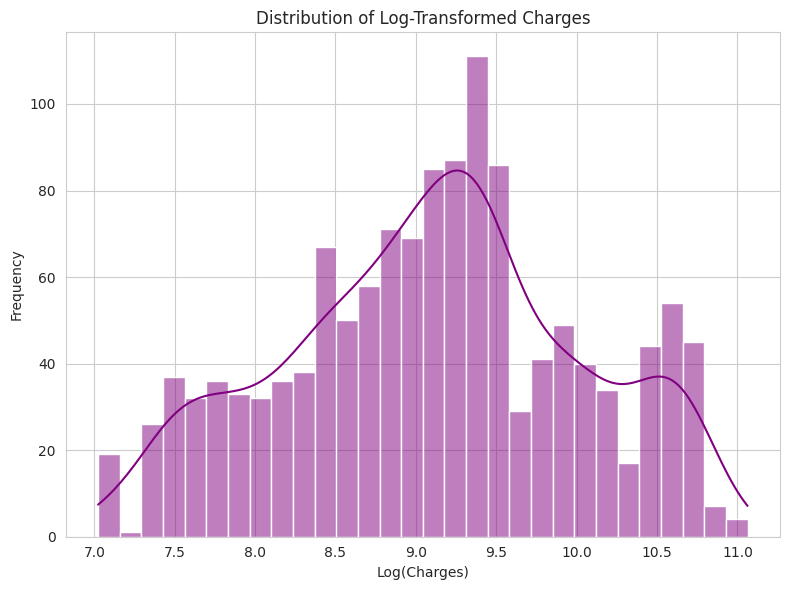

In [ ]:
# Display descriptive statistics for the new log-transformed charges
print('Descriptive statistics for log-transformed charges:')
display(df_fe['charges_log'].describe())

# Visualize the distribution of log-transformed charges
plt.figure(figsize=(8, 6))
sns.histplot(df_fe['charges_log'], kde=True, bins=30, color='purple')
plt.title('Distribution of Log-Transformed Charges')
plt.xlabel('Log(Charges)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Model Selection, Training, and Tuning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Define features (X) and target (y)
# Drop the original 'charges' and 'charges_log' from features
X = df_fe.drop(columns=['charges', 'charges_log'])
y = df_fe['charges_log']

# Display the shape of X and y
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

print('\nFirst 5 rows of features (X):')
display(X.head())

print('\nFirst 5 rows of target (y):')
display(y.head())

Shape of features (X): (1338, 12)
Shape of target (y): (1338,)

First 5 rows of features (X):


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age_interaction,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight
0,19,27.900,0,False,True,False,False,True,530.100,False,True,False
1,18,33.770,1,True,False,False,True,False,607.860,True,False,False
2,28,33.000,3,True,False,False,True,False,924.000,True,False,False
3,33,22.705,0,True,False,True,False,False,749.265,False,False,False
4,32,28.880,0,True,False,True,False,False,924.160,False,True,False



First 5 rows of target (y):


,charges_log
0,9.734236
1,7.453882
2,8.400763
3,9.998137
4,8.260455


Now that we have defined our features (X) and target (y), we need to split our dataset into training and testing sets. This is a crucial step to evaluate how well our model generalizes to unseen data.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Testing set shape (X_test, y_test): {X_test.shape}, {y_test.shape}")

Training set shape (X_train, y_train): (1070, 12), (1070,)
Testing set shape (X_test, y_test): (268, 12), (268,)


Let's start with a simple **Linear Regression model** as a baseline to understand its performance on our dataset.

In [ ]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"  R-squared (R2): {r2_lr:.4f}")

Linear Regression Model Performance:
  Mean Squared Error (MSE): 0.1774
  R-squared (R2): 0.8026


Next, let's try a more sophisticated model, the **RandomForestRegressor**, which often provides better accuracy. We'll first train it with default parameters and then proceed to tune it.

In [ ]:
# Initialize and train the RandomForestRegressor model with default parameters
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RandomForestRegressor Model Performance (Default Parameters):")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  R-squared (R2): {r2_rf:.4f}")

RandomForestRegressor Model Performance (Default Parameters):
  Mean Squared Error (MSE): 0.1388
  R-squared (R2): 0.8456


To further optimize the RandomForestRegressor, we will perform **hyperparameter tuning using GridSearchCV**. This helps find the best combination of parameters for our model.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': [0.8, 1.0], # Number of features to consider when looking for the best split
    'max_depth': [None, 10, 20], # Maximum number of levels in tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Display progress
    scoring='r2' # Metric to optimize
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score: {grid_search.best_score_:.4f}")

# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the best model
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"\nRandomForestRegressor Model Performance (After GridSearchCV Tuning):")
print(f"  Mean Squared Error (MSE): {mse_best_rf:.4f}")
print(f"  R-squared (R2): {r2_best_rf:.4f}")

# --- Prediction for a new input (corrected) ---

# Define the raw input data using original categories as strings
input_data_raw = pd.DataFrame({
    'age': [62],
    'sex': ['female'],  # Assuming 1 for male
    'bmi': [26.29],
    'children': [0],
    'smoker': ['yes'], # Assuming 0 for no
    'region': ['southeast'] # Assuming 0 for southeast
})

# Replicate the one-hot encoding for categorical features
input_df_encoded = pd.get_dummies(input_data_raw, columns=['sex', 'smoker', 'region'], drop_first=True)

# Replicate the feature engineering
input_df_fe = input_df_encoded.copy()
input_df_fe['bmi_age_interaction'] = input_df_fe['bmi'] * input_df_fe['age']

def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 24.9:
        return 'Normal'
    elif 25 <= bmi < 29.9:
        return 'Overweight'
    else:
        return 'Obese'

input_df_fe['bmi_category'] = input_df_fe['bmi'].apply(get_bmi_category)
input_df_fe = pd.get_dummies(input_df_fe, columns=['bmi_category'], drop_first=True)

# Ensure the input DataFrame has all the columns present in X_train and in the same order
# Initialize a DataFrame with all X_train columns, filled with appropriate default values
final_input_for_prediction = pd.DataFrame(columns=X_train.columns, index=[0])

# Fill numerical columns
final_input_for_prediction['age'] = input_df_fe['age']
final_input_for_prediction['bmi'] = input_df_fe['bmi']
final_input_for_prediction['children'] = input_df_fe['children']
final_input_for_prediction['bmi_age_interaction'] = input_df_fe['bmi_age_interaction']

# Fill boolean (one-hot encoded) columns
# Set all to False first
for col in X_train.columns:
    if col.startswith(('sex_', 'smoker_', 'region_', 'bmi_category_')):
        final_input_for_prediction[col] = False

# Then set True for the specific categories present in the input
for col in input_df_fe.columns:
    if col in final_input_for_prediction.columns:
        final_input_for_prediction[col] = input_df_fe[col]

# Ensure data types match the training data
final_input_for_prediction = final_input_for_prediction.astype(X_train.dtypes)

# Predict using the prepared input DataFrame
prediction_log = best_rf_model.predict(final_input_for_prediction)

# Inverse transform the log-transformed prediction to get actual charges
predicted_charges = np.expm1(prediction_log[0])

print(f"\nThe predicted insurance charge for the given input is USD {predicted_charges:.2f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters found: {'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best R-squared score: 0.8097

RandomForestRegressor Model Performance (After GridSearchCV Tuning):
  Mean Squared Error (MSE): 0.1259
  R-squared (R2): 0.8599

The predicted insurance charge for the given input is USD 13934.52


In [ ]:
import joblib

# Save the best model to a file
joblib.dump(best_rf_model, 'model.pkl')

print("Model saved as 'model.pkl'")

Model saved as 'model.pkl'
